In [2]:
## Eugene Kim, 02/27/2024 

## I'm going to demonstrate how to do simple pair trading between two stocks using Python. ##

#Import Libraries
import yfinance as yf
import seaborn as sns
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Get Sample Datasets

stocks=["MSFT","AAPL","NVDA","AMZN","META","TSM"]
df={}
for stock in stocks:
    ticker=yf.Ticker(stock)
    hist=ticker.history(period="3d",interval="1m")
    df[stock]=hist["Close"]
df=pd.DataFrame(df)
df.head()


,MSFT,AAPL,NVDA,AMZN,META,TSM
Datetime,,,,,,
2024-02-23 09:30:00-05:00,414.660004,184.695007,805.594971,174.789993,491.820007,130.399994
2024-02-23 09:31:00-05:00,415.109985,184.850006,809.789978,175.217896,491.989990,130.647598
2024-02-23 09:32:00-05:00,415.020111,184.811401,812.429871,175.070007,491.521393,130.889999
2024-02-23 09:33:00-05:00,415.079987,184.559998,815.674988,174.779404,491.950012,130.880005
2024-02-23 09:34:00-05:00,415.399994,184.649994,820.162781,174.630005,492.249908,130.960007


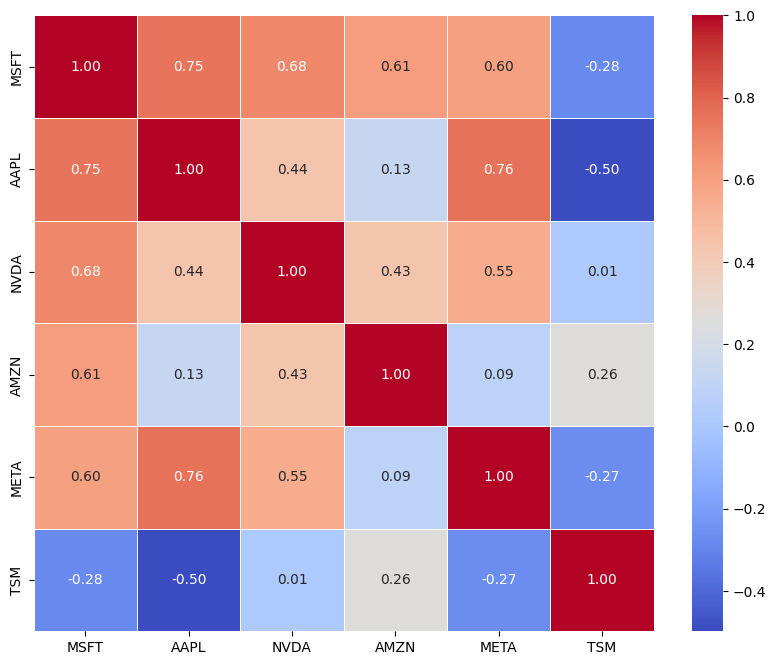

Best Pair is: (0.7598761754664538, ('AAPL', 'META'))


In [4]:
# Find the pair with the highest correlation and plot the correlation matrix

mat=df.corr()
pair=np.triu(np.ones(mat.shape),k=1).astype(bool)

plt.figure(figsize=(10, 8))
sns.heatmap(mat,annot=True,cmap='coolwarm',fmt=".2f",linewidths=.5)
plt.show()

X=mat.where(pair).stack().max()
Y=mat.where(pair).stack().idxmax()
print(f"Best Pair is: {X,Y}")


In [5]:
# Define the pair trading function

def pair_trading(X,Y):
    
    # Calculate the spread (price difference) between Y and X
    spread=Y-X

    # Calculate z-score 
    zscore=(spread-spread.mean())/spread.std()

    # Define entry and exit signals based on z-score 
    entry_zscore=-2
    exit_zscore=0

    long_signal=(zscore<entry_zscore)&(zscore.shift(1)>entry_zscore)
    short_signal=(zscore>-entry_zscore)&(zscore.shift(1)<-entry_zscore)

    # Initialize variables for backtesting
    initial_capital=10000  # Initial capital
    cash=initial_capital
    Y_shares=0
    X_shares=0
    total_value=[]

    # Prepare to collect trade logs
    trade_logs=[]

    for i in range(len(spread)):
        action="Hold"
        Y_shares_change=0
        X_shares_change=0
        if long_signal.iloc[i]:
            action="LongY&ShortX"
            Y_shares_to_buy=cash//Y.iloc[i]
            X_shares_to_sell=cash//X.iloc[i]
            cash-=Y_shares_to_buy*Y.iloc[i]
            cash+=X_shares_to_sell*X.iloc[i]
            Y_shares+=Y_shares_to_buy
            X_shares-=X_shares_to_sell
            Y_shares_change=Y_shares_to_buy
            X_shares_change=-X_shares_to_sell
        elif short_signal.iloc[i]:
            action="ShortY&LongX"
            Y_shares_to_sell=cash//Y.iloc[i]
            X_shares_to_buy=cash//X.iloc[i]
            cash+=Y_shares_to_sell*Y.iloc[i]
            cash-=X_shares_to_buy*X.iloc[i]
            Y_shares-=Y_shares_to_sell
            X_shares+=X_shares_to_buy
            Y_shares_change=-Y_shares_to_sell
            X_shares_change=X_shares_to_buy
        
        total_portfolio_value=cash+Y_shares*Y.iloc[i]+X_shares*X.iloc[i]
        total_value.append(total_portfolio_value)

        # Collect data for the trade log
        trade_logs.append({
            "Timestamp":i,  
            "Action":action,
            "Y_Shares":Y_shares_change,
            "X_Shares":X_shares_change,
            "Cash":cash,
            "P/L":total_portfolio_value-initial_capital
        })

    # Convert the collected trade logs into a DataFrame
    trade_log=pd.DataFrame(trade_logs)
    trade_log.set_index("Timestamp",inplace=True)

    # Calculate the total profit, total trades, and average profit per trade
    final_profit=total_value[-1]-initial_capital
    trade_actions=trade_log[trade_log["Action"]!="Hold"]
    total_trades=len(trade_actions)
    average_profit_per_trade=final_profit/total_trades if total_trades > 0 else 0
    percentprofit=final_profit/initial_capital*100   

   # Print the total profit, total trades, and average profit per trade
    print(f"Total Profit and % gain: ${final_profit:.2f},  {percentprofit:.2f}%")
    print(f"Total Trades Executed: {total_trades}")
    print(f"Average Profit per Trade: ${average_profit_per_trade:.2f}")

    # Plotting the total portfolio value over time
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(total_value)), total_value, color="blue")
    plt.title("Total Portfolio Value Over Time")
    plt.xlabel("Time")
    plt.ylabel("Total Portfolio Value")
    plt.grid(True)
    plt.show()

    # Return the total profit, total trades, and average profit for further analysis if needed
    return final_profit, total_trades, average_profit_per_trade




Total Profit and % gain: $144.85,  1.45%
Total Trades Executed: 3
Average Profit per Trade: $48.28


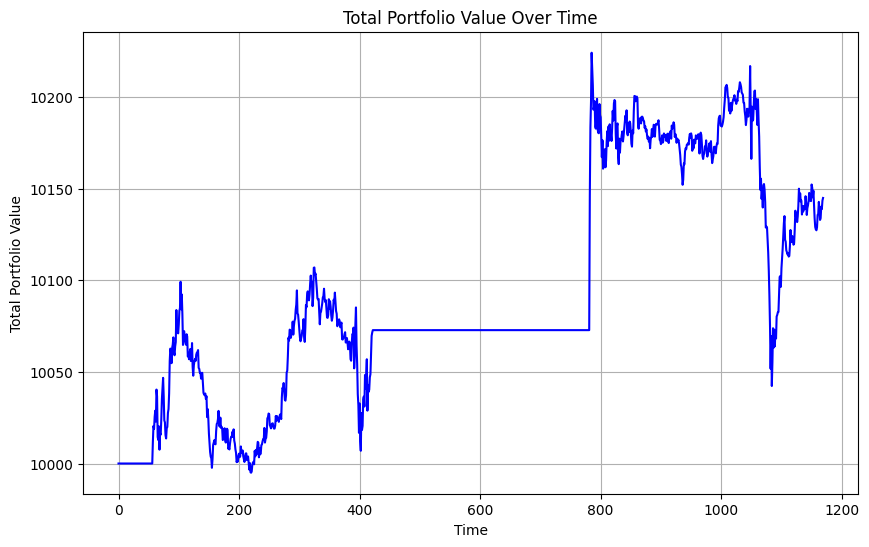

(144.84962463378906, 3, 48.28320821126302)

In [6]:
# Execute the pair trading strategy on the best pair found

pair_trading(df["AAPL"],df["META"])